### **Libraries**

In [78]:
import re
import numpy as np
import pandas as pd
from collections import Counter
from itertools import chain

%matplotlib widget
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))

### **Import the dataset (original-wn)**

In [79]:
df = pd.read_csv("datasets/original-wn-dataset.csv")
df.describe(include="all")

,novel_id,url,title,associated_names,img_url,showtype,genres,tags,description,related_series,...,publishers,en_pubs,release_frequency,weekly_rank,monthly_rank,all_time_rank,monthly_rank_reading_list,all_time_rank_reading_list,total_reading_list_rank,chapters
count,11770.000000,11770,11770,11770,11770,11700,11770,11770,11766,11770,...,11770,11770,11769,11770,11770,11770,11770,11770,11770.000000,11770
unique,NaN,11770,11768,11619,10159,20,6014,11215,11676,1325,...,1213,69,3721,474,2600,8282,3091,6533,NaN,10488
top,NaN,after-the-breakup-i-went-viral-in-the-entertai...,The Imperial Concubine Just Wants To Be a Salt...,[],https://www.novelupdates.com/img/noimagefound.jpg,Web Novel (CN),['Fantasy' 'Romance'],[],N/A\n,"{'related_series': array([], dtype=object), 't...",...,['jjwxc'],[],Every 2000 Day(s),#2000,#2000,#14613,#15649,#11754,NaN,"{'chapters': array([], dtype=object), 'total': 0}"
freq,NaN,1,2,97,1607,5592,230,155,66,10398,...,2216,10454,118,6097,5699,13,418,13,NaN,1283
mean,34047.713084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1664.066950,NaN
std,19129.992708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2436.728268,NaN
min,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,NaN
25%,18403.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,300.000000,NaN
50%,35094.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740.000000,NaN
75%,50761.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1981.000000,NaN


For our NLP classification task, we are interested on the following columns `novel_id`, `title`, `genres`, `tags` and `description`.

In [80]:
df_filtered = df.loc[:, ["novel_id", "title", "genres", "tags", "description"]]
df_filtered.head()

,novel_id,title,genres,tags,description
0,64494,"After the Breakup, I Went Viral in the Enterta...",['Drama' 'Fantasy' 'Romance' 'Supernatural'],['Amnesia' 'Beautiful Female Lead' 'Clever Pro...,"Luo Ning was a cannon fodder, a female support..."
1,43962,Mahou Sekai no Monogatari,['Fantasy' 'Romance' 'Shoujo'],['Adventurers' 'Elemental Magic' 'Familiars' '...,A world where magic exists.\nThis is the story...
2,25506,I am a Good Man,['Action' 'Adventure' 'Fantasy' 'Historical' '...,['Beautiful Female Lead' 'Businessmen' 'Childc...,"To sum up in a sentence, transmigrating to dif..."
3,50373,Scum Girl Practice Manual,['Romance' 'School Life' 'Shoujo'],['Female Protagonist' 'Modern Day' 'Short Stor...,"My goal is, to be a scum woman.\n"
4,48291,Unable to Divorce After Signing the Marriage C...,['Psychological' 'Romance' 'Shounen Ai' 'Slice...,['Arranged Marriage' 'Calm Protagonist' 'Cold ...,Lin You He excelled in everything – his looks...


### **Preprocess Dataset Format**

Using the `.head()` command, we observe that the `genres` and `tags` columns are encoded into space separated list, which are not recognised in Python, so we will have to change the format to proper lists.

In [81]:
def colToList (x:str) -> list[str]:
    # Detect the separator
    x = re.sub(r"'[\n ].?'", ",",x)
    
    # Remove the indicator of the raw space separated list and split on coma
    xSplit = x.removeprefix("['").removesuffix("']").split(",")
    
    # Return the list where the text is capitalize (it is just prettier)
    return list(map(str.capitalize, xSplit))

# Apply the split
df_filtered.loc[:,"genres"] = df_filtered.loc[:,"genres"].apply(lambda x: colToList(x))
df_filtered.loc[:,"tags"] = df_filtered.loc[:,"tags"].apply(lambda x: colToList(x))
df_filtered.head()

,novel_id,title,genres,tags,description
0,64494,"After the Breakup, I Went Viral in the Enterta...","[Drama, Fantasy, Romance, Supernatural]","[Amnesia, Beautiful female lead, Clever protag...","Luo Ning was a cannon fodder, a female support..."
1,43962,Mahou Sekai no Monogatari,"[Fantasy, Romance, Shoujo]","[Adventurers, Elemental magic, Familiars, Fema...",A world where magic exists.\nThis is the story...
2,25506,I am a Good Man,"[Action, Adventure, Fantasy, Historical, Roman...","[Beautiful female lead, Businessmen, Childcare...","To sum up in a sentence, transmigrating to dif..."
3,50373,Scum Girl Practice Manual,"[Romance, School life, Shoujo]","[Female protagonist, Modern day, Short story, ...","My goal is, to be a scum woman.\n"
4,48291,Unable to Divorce After Signing the Marriage C...,"[Psychological, Romance, Shounen ai, Slice of ...","[Arranged marriage, Calm protagonist, Cold pro...",Lin You He excelled in everything – his looks...


### **Some stats on the dataset**
Now that everything is correctly imported, we will observe some statistics on our dataset to understand it.
##### **Description language** 

C:\Users\arnol\AppData\Local\Temp\ipykernel_22332\1866244222.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


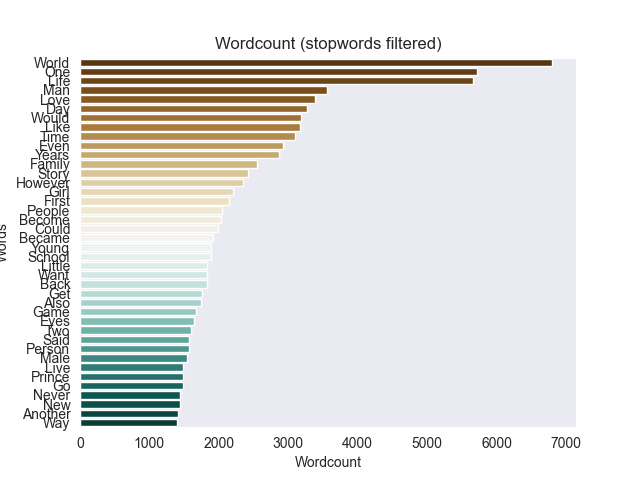

In [86]:
descriptionList = list(map(str,df_filtered.loc[:,"description"].to_list()))
descriptionString = " ".join(descriptionList)
# Match all words and digits
wordDescriptionList = re.findall(r"[\w\d-]+",descriptionString)

# Remove the stopwords
wordDescriptionList = [i.capitalize() for i in wordDescriptionList if i.lower() not in stop_words]

# Apply the counter
wordDescriptionListCounter = Counter(wordDescriptionList)

# Sort the counter
wordDescriptionListCounterSorted = [[],[]]
for word in sorted(wordDescriptionListCounter, key=lambda x:wordDescriptionListCounter[x], reverse=True):
    wordDescriptionListCounterSorted[0].append(word)
    wordDescriptionListCounterSorted[1].append(wordDescriptionListCounter[word])

# Make a plot
plt.close("all")
sns.set_style("dark")
sns.barplot(
    x=wordDescriptionListCounterSorted[1][:40],
    y=wordDescriptionListCounterSorted[0][:40],
    palette="BrBG"    
)
plt.title("Wordcount (stopwords filtered)")
plt.xlabel("Wordcount")
plt.ylabel("Words")

plt.show()

##### **Genres stats**
First how genres are distributed:

[['Romance', 'Fantasy', 'Comedy', 'Action', 'Drama', 'Adventure', 'Slice of life', 'Harem', 'School life', 'Supernatural', 'Yaoi', 'Mature', 'Adult', 'Mystery', 'Josei', 'Tragedy', 'Martial arts', 'Shounen', 'Shoujo', 'Sci-fi', 'Psychological', 'Smut', 'Shounen ai', 'Xuanhuan', 'Historical', 'Seinen', 'Ecchi', 'Horror', 'Xianxia', 'Gender bender', 'Yuri', 'Mecha', 'Shoujo ai', 'Wuxia', 'Sports'], [7523, 6309, 4105, 3743, 3672, 3332, 2210, 2048, 1743, 1731, 1627, 1486, 1277, 1043, 1042, 984, 941, 935, 903, 886, 865, 784, 769, 673, 669, 639, 580, 406, 377, 313, 294, 184, 118, 112, 106]]


C:\Users\arnol\AppData\Local\Temp\ipykernel_22332\3904004382.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


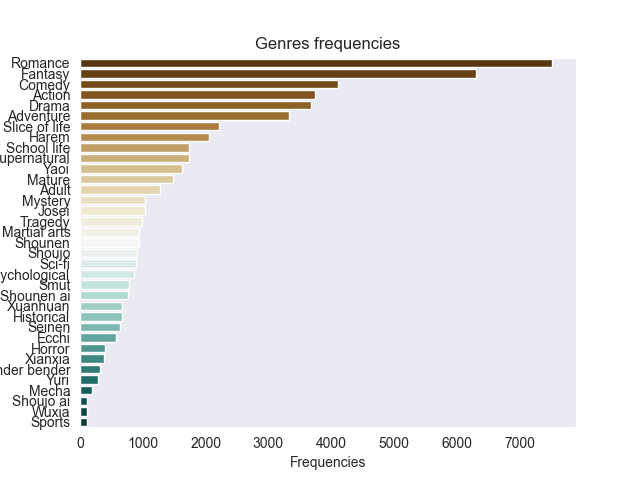

In [87]:
# Get a flatten list of genre
genresList = list(chain.from_iterable(df_filtered.loc[:,"genres"].tolist()))

# Make a counter and sort it
genresCounter = Counter(genresList)
genresCounterSorted = [[],[]]
for genre in sorted(genresCounter, key=lambda x:genresCounter[x], reverse=True):
    genresCounterSorted[0].append(genre)
    genresCounterSorted[1].append(genresCounter[genre])

print(genresCounterSorted)
# Make a plot
plt.close("all")
sns.set_style("dark")
sns.barplot(
    x=genresCounterSorted[1],
    y=genresCounterSorted[0],
    palette="BrBG"    
)
plt.title("Genres frequencies")
plt.xlabel("Frequencies")
plt.ylabel("Genres")

plt.show()

Second, how do genres interacts togethers: 

In [84]:
# Create the genre id dictionary
genreToGenreID = {genre:i for i, genre in enumerate(set(genresList))}
genreIDtoGenre = {value:key for key, value in genreToGenreID.items()}
print(genreToGenreID, genreIDtoGenre, sep="\n")

# Create the genreCount dictionary
genreMatrix = np.zeros((len(genreIDtoGenre),len(genreIDtoGenre)), dtype=int)

## For all genres
for genres in df_filtered.loc[:,"genres"].tolist():
    # If it is the only genre, then loop to itself
    if len(genres)==1:
        genreMatrix[genreToGenreID[genres[0]], genreToGenreID[genres[0]]] += 1
        continue
    # Otherwise, add a link to all couple of genre which are differerent
    for genre1 in genres:
        for genre2 in genres:
            if genre1 != genre2:
                genreMatrix[genreToGenreID[genre1], genreToGenreID[genre2]] += 1
print(genreMatrix)

{'Drama': 0, 'Smut': 1, 'Yaoi': 2, 'Shoujo ai': 3, 'Adventure': 4, 'Shounen': 5, 'Yuri': 6, 'Action': 7, 'Xianxia': 8, 'Comedy': 9, 'Harem': 10, 'Martial arts': 11, 'Sports': 12, 'Sci-fi': 13, 'Historical': 14, 'School life': 15, 'Shounen ai': 16, 'Gender bender': 17, 'Fantasy': 18, 'Mecha': 19, 'Slice of life': 20, 'Mature': 21, 'Shoujo': 22, 'Ecchi': 23, 'Wuxia': 24, 'Supernatural': 25, 'Adult': 26, 'Josei': 27, 'Horror': 28, 'Mystery': 29, 'Romance': 30, 'Seinen': 31, 'Tragedy': 32, 'Xuanhuan': 33, 'Psychological': 34}
{0: 'Drama', 1: 'Smut', 2: 'Yaoi', 3: 'Shoujo ai', 4: 'Adventure', 5: 'Shounen', 6: 'Yuri', 7: 'Action', 8: 'Xianxia', 9: 'Comedy', 10: 'Harem', 11: 'Martial arts', 12: 'Sports', 13: 'Sci-fi', 14: 'Historical', 15: 'School life', 16: 'Shounen ai', 17: 'Gender bender', 18: 'Fantasy', 19: 'Mecha', 20: 'Slice of life', 21: 'Mature', 22: 'Shoujo', 23: 'Ecchi', 24: 'Wuxia', 25: 'Supernatural', 26: 'Adult', 27: 'Josei', 28: 'Horror', 29: 'Mystery', 30: 'Romance', 31: 'Seine

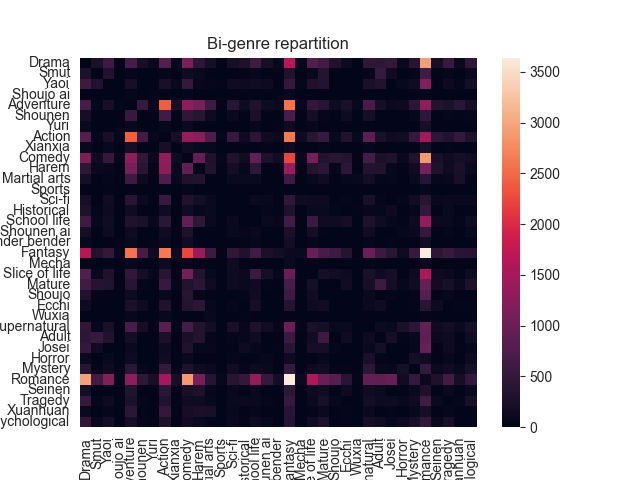

In [85]:
# Make a plot
plt.close("all")
sns.heatmap(genreMatrix,
            xticklabels=list(genreToGenreID.keys()),
            yticklabels=list(genreToGenreID.keys()))
plt.title("Bi-genre repartition")
plt.xlabel("Genre")
plt.ylabel("Genre")

plt.show()

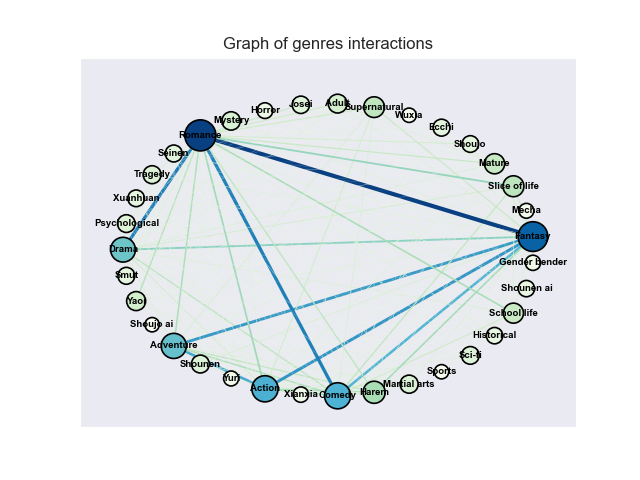

In [ ]:
# Make the graph for visibility
G = nx.from_numpy_array(genreMatrix)
G = nx.relabel_nodes(G, dict(enumerate(list(genreToGenreID.keys()))))

# Compute the weights of each edges for the graph
weights = np.array(list(nx.get_edge_attributes(G,"weight").values()))
weights = weights/weights.max()

# Compute the degree of each node to infer nodes sizes
deg = dict(G.degree(weight="weight"))
node_sizes = [100 + 400 * deg[n] / max(deg.values()) for n in G.nodes()]

# Plot the graph
plt.close("all")
nx.draw_networkx(
                 G,                         # The graph 
                 pos=nx.shell_layout(G),    # The layout
                 width=3*weights,           # The width of the edges
                 edge_color=weights,        # Edge colour defined by the weights
                 edge_cmap=plt.cm.GnBu,     # Colour map of the edges
                 font_size="x-small",       # The font size
                 font_color="black",        # The font colour
                 font_weight="bold",        # We want bold
                 font_family="Arial",       # We want Arial
                 node_size=node_sizes,      # The size of the nodes
                 edgecolors="black",        # The border colour of the nodes
                 linewidths=1.2,            # Contour colour of the nodes
                 node_color=node_sizes,     # Colour of the node depends on the degree
                 cmap=plt.cm.GnBu           # Colour map of the nodes
)

# Show the graph
plt.title("Graph of genres interactions")
plt.show()